In [1]:
# Import basic libraries for data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import Path to find dataset files
from pathlib import Path

# Show more columns when displaying dataframes
pd.set_option("display.max_columns", 100)

# Find CSV files inside Kaggle input folder
input_dir = Path("/kaggle/input")
csv_files = list(input_dir.rglob("*.csv"))

# Display available CSV files
csv_files

[PosixPath('/kaggle/input/datasets/jessemostipak/hotel-booking-demand/hotel_bookings.csv')]

# Hotel Booking Demand Analysis: Revenue Drivers and Cancellation Risk

## Project Objective

This project analyzes hotel booking demand data to identify seasonal demand patterns, cancellation risks, ADR trends, and estimated revenue at risk across city and resort hotels.

The goal is to connect data analysis with hotel revenue management decisions, including pricing strategy, cancellation management, and booking channel optimization.

## Main Business Questions

1. How do booking patterns differ between city hotels and resort hotels?
2. Which factors are associated with higher cancellation risk?
3. How does ADR vary by month, hotel type, and market segment?
4. What estimated revenue is at risk due to canceled bookings?
5. What business recommendations can hotels use based on the analysis?

## 1. Data Loading

The dataset was loaded from the Kaggle input directory using pandas.  
The first five rows were previewed to confirm that the dataset was imported correctly.

In [2]:
# Select the hotel booking CSV file
data_path = [file for file in csv_files if "hotel" in file.name.lower()][0]

# Load the dataset
df = pd.read_csv(data_path)

# Preview the first 5 rows
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Initial Data Inspection

The dataset includes hotel booking records with information such as hotel type, cancellation status, lead time, arrival date, length of stay, number of guests, market segment, distribution channel, customer type, and ADR.

Initial inspection was conducted to understand the dataset size, column types, summary statistics, and missing values before cleaning the data.

In [3]:
# Check the number of rows and columns
df.shape

(119390, 32)

In [4]:
# Display all column names
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [5]:
# Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
# Show summary statistics for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [7]:
# Check missing values by column
missing_values = df.isna().sum().sort_values(ascending=False)

# Display columns with missing values only
missing_values[missing_values > 0]

company     112593
agent        16340
country        488
children         4
dtype: int64

## 3. Data Cleaning

Before analysis, missing values and unusual records were handled to improve data quality.

The cleaning process included:

1. Filling missing values in `children`, `country`, `agent`, and `company`.
2. Creating total guest and total night variables.
3. Removing records with zero guests.
4. Removing records with zero total nights.
5. Removing records with negative ADR values.
6. Reviewing extreme ADR values before final revenue analysis.

In [8]:
# Create a copy of the original dataset for cleaning
hotel = df.copy()

# Check original data size
hotel.shape

(119390, 32)

In [9]:
# Fill missing children values with 0
# Reason: missing children likely means no children were included in the booking
hotel["children"] = hotel["children"].fillna(0)

# Fill missing country values with "Unknown"
# Reason: country is categorical, so "Unknown" keeps the row without guessing a country
hotel["country"] = hotel["country"].fillna("Unknown")

# Fill missing agent and company values with 0
# Reason: missing values likely indicate that no agent or company was associated with the booking
hotel["agent"] = hotel["agent"].fillna(0)
hotel["company"] = hotel["company"].fillna(0)

# Convert children to integer after filling missing values
hotel["children"] = hotel["children"].astype(int)

# Check missing values again
hotel.isna().sum().sort_values(ascending=False).head()

hotel                 0
is_canceled           0
lead_time             0
arrival_date_year     0
arrival_date_month    0
dtype: int64

Missing values were handled instead of being removed because columns such as `company` and `agent` had many missing values. Removing all rows with missing values would significantly reduce the dataset size.

After filling missing values, the dataset no longer contains missing values.

In [10]:
# Confirm that there are no missing values left
hotel.isna().sum().sum()

np.int64(0)

In [11]:
# Create total number of guests
hotel["total_guests"] = hotel["adults"] + hotel["children"] + hotel["babies"]

# Create total length of stay
hotel["total_nights"] = hotel["stays_in_weekend_nights"] + hotel["stays_in_week_nights"]

# Preview the new columns
hotel[[
    "adults", 
    "children", 
    "babies", 
    "total_guests",
    "stays_in_weekend_nights", 
    "stays_in_week_nights", 
    "total_nights"
]].head()

,adults,children,babies,total_guests,stays_in_weekend_nights,stays_in_week_nights,total_nights
0,2,0,0,2,0,0,0
1,2,0,0,2,0,0,0
2,1,0,0,1,0,1,1
3,1,0,0,1,0,1,1
4,2,0,0,2,0,2,2


In [12]:
# Check unusual records before removing them
zero_guest_count = (hotel["total_guests"] == 0).sum()
zero_night_count = (hotel["total_nights"] == 0).sum()
negative_adr_count = (hotel["adr"] < 0).sum()

print("Rows with zero guests:", zero_guest_count)
print("Rows with zero total nights:", zero_night_count)
print("Rows with negative ADR:", negative_adr_count)

Rows with zero guests: 180
Rows with zero total nights: 715
Rows with negative ADR: 1


In [13]:
# Count rows that meet at least one invalid condition
invalid_records = hotel[
    (hotel["total_guests"] == 0) |
    (hotel["total_nights"] == 0) |
    (hotel["adr"] < 0)
]

# Display the number of unique invalid records
print("Total unique invalid records:", len(invalid_records))

# Preview invalid records
invalid_records[[
    "hotel",
    "is_canceled",
    "adults",
    "children",
    "babies",
    "total_guests",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "total_nights",
    "adr"
]].head(10)

Total unique invalid records: 826


,hotel,is_canceled,adults,children,babies,total_guests,stays_in_weekend_nights,stays_in_week_nights,total_nights,adr
0,Resort Hotel,0,2,0,0,2,0,0,0,0.0
1,Resort Hotel,0,2,0,0,2,0,0,0,0.0
167,Resort Hotel,0,2,0,0,2,0,0,0,0.0
168,Resort Hotel,0,1,0,0,1,0,0,0,0.0
196,Resort Hotel,0,2,0,0,2,0,0,0,0.0
197,Resort Hotel,0,2,0,0,2,0,0,0,0.0
459,Resort Hotel,0,2,0,0,2,0,0,0,0.0
568,Resort Hotel,0,1,0,0,1,0,0,0,0.0
569,Resort Hotel,0,2,0,0,2,0,0,0,0.0
618,Resort Hotel,0,2,2,0,4,0,0,0,0.0


In [14]:
# Keep only valid booking records for demand and revenue analysis
valid_condition = (
    (hotel["total_guests"] > 0) &
    (hotel["total_nights"] > 0) &
    (hotel["adr"] >= 0)
)

hotel = hotel[valid_condition].copy()

# Check cleaned data size after removing invalid records
hotel.shape

(118564, 34)

In [15]:
# Confirm invalid records were removed
print("Rows with zero guests:", (hotel["total_guests"] == 0).sum())
print("Rows with zero total nights:", (hotel["total_nights"] == 0).sum())
print("Rows with negative ADR:", (hotel["adr"] < 0).sum())

Rows with zero guests: 0
Rows with zero total nights: 0
Rows with negative ADR: 0


Records with zero guests, zero total nights, or negative ADR values were removed because they are not appropriate for hotel demand and revenue analysis.

Zero-guest bookings do not represent actual guest demand, zero-night bookings cannot be used for length-of-stay or revenue proxy calculations, and negative ADR values are not meaningful for room revenue analysis.

After this step, the dataset contains 118,564 rows and 34 columns.

### ADR Quality Check

After removing invalid records, ADR values were reviewed because ADR is a key variable for pricing and revenue analysis.

This step checks zero ADR values and extreme ADR values before creating revenue-related variables.

In [16]:
# Check ADR distribution after removing invalid records
hotel["adr"].describe()

count    118564.000000
mean        102.524728
std          50.004752
min           0.000000
25%          70.000000
50%          95.000000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

In [17]:
# Check ADR percentiles to understand extreme values
hotel["adr"].quantile([0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00])

0.00       0.000
0.01       1.926
0.05      40.000
0.25      70.000
0.50      95.000
0.75     126.000
0.95     194.000
0.99     252.000
1.00    5400.000
Name: adr, dtype: float64

In [18]:
# Check zero ADR and extremely high ADR records
zero_adr_count = (hotel["adr"] == 0).sum()
high_adr_count = (hotel["adr"] > 1000).sum()

print("Rows with ADR equal to 0:", zero_adr_count)
print("Rows with ADR greater than 1000:", high_adr_count)

Rows with ADR equal to 0: 1165
Rows with ADR greater than 1000: 1


In [19]:
# Preview records with extremely high ADR
high_adr = hotel[hotel["adr"] > 1000]

high_adr[[
    "hotel",
    "is_canceled",
    "arrival_date_year",
    "arrival_date_month",
    "adr",
    "total_nights",
    "market_segment",
    "distribution_channel",
    "customer_type",
    "reserved_room_type",
    "assigned_room_type"
]]

,hotel,is_canceled,arrival_date_year,arrival_date_month,adr,total_nights,market_segment,distribution_channel,customer_type,reserved_room_type,assigned_room_type
48515,City Hotel,1,2016,March,5400.0,1,Offline TA/TO,TA/TO,Transient,A,A


In [20]:
# Create a separate dataset for ADR and revenue-related analysis
# Keep only records with positive ADR and remove extreme ADR outliers
hotel_revenue = hotel[
    (hotel["adr"] > 0) &
    (hotel["adr"] <= 1000)
].copy()

# Check the size of the revenue analysis dataset
hotel_revenue.shape

(117398, 34)

In [21]:
# Confirm ADR values in the revenue analysis dataset
print("Rows with ADR equal to 0:", (hotel_revenue["adr"] == 0).sum())
print("Rows with ADR greater than 1000:", (hotel_revenue["adr"] > 1000).sum())

# Check ADR distribution after filtering
hotel_revenue["adr"].describe()

Rows with ADR equal to 0: 0
Rows with ADR greater than 1000: 0


count    117398.000000
mean        103.497009
std          46.701276
min           0.260000
25%          70.530000
50%          95.000000
75%         126.000000
max         510.000000
Name: adr, dtype: float64

For demand and cancellation analysis, the cleaned `hotel` dataset was retained because zero ADR records can still represent booking activity.

For ADR and revenue-related analysis, a separate dataset named `hotel_revenue` was created. Records with ADR equal to 0 were excluded because they do not represent meaningful paid room rates for pricing analysis. One record with ADR greater than 1000 was also excluded because it was an extreme outlier compared with the 99th percentile ADR value.

This approach avoids removing potentially useful booking records from demand analysis while protecting ADR and revenue analysis from distorted results.

## 4. Feature Engineering

Additional variables were created to support time-based analysis, cancellation risk analysis, and revenue management analysis.

The feature engineering process includes creating arrival date variables, lead time groups, and revenue-related variables.

In [22]:
# Create full arrival date column for the main cleaned dataset
arrival_date_text = (
    hotel["arrival_date_year"].astype(str) + "-" +
    hotel["arrival_date_month"].astype(str) + "-" +
    hotel["arrival_date_day_of_month"].astype(str)
)

hotel["arrival_date"] = pd.to_datetime(
    arrival_date_text,
    format="%Y-%B-%d",
    errors="coerce"
)

# Create year-month column for monthly trend analysis
hotel["arrival_year_month"] = hotel["arrival_date"].dt.to_period("M").astype(str)

# Preview the new date columns
hotel[[
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_day_of_month",
    "arrival_date",
    "arrival_year_month"
]].head()

,arrival_date_year,arrival_date_month,arrival_date_day_of_month,arrival_date,arrival_year_month
2,2015,July,1,2015-07-01,2015-07
3,2015,July,1,2015-07-01,2015-07
4,2015,July,1,2015-07-01,2015-07
5,2015,July,1,2015-07-01,2015-07
6,2015,July,1,2015-07-01,2015-07


In [23]:
# Check if any arrival dates could not be created
hotel["arrival_date"].isna().sum()

np.int64(0)

In [24]:
# Update the revenue analysis dataset after creating date-related columns
# This ensures that hotel_revenue includes the same engineered date columns as hotel
hotel_revenue = hotel[
    (hotel["adr"] > 0) &
    (hotel["adr"] <= 1000)
].copy()

# Check updated revenue analysis dataset size
hotel_revenue.shape

(117398, 36)

In [25]:
# Confirm date columns exist in hotel_revenue
hotel_revenue[[
    "arrival_date",
    "arrival_year_month",
    "adr"
]].head()

,arrival_date,arrival_year_month,adr
2,2015-07-01,2015-07,75.0
3,2015-07-01,2015-07,75.0
4,2015-07-01,2015-07,98.0
5,2015-07-01,2015-07,98.0
6,2015-07-01,2015-07,107.0


In [26]:
# Create lead time groups for cancellation risk analysis
lead_time_bins = [-1, 7, 30, 90, 180, 365, float("inf")]

lead_time_labels = [
    "0-7 days",
    "8-30 days",
    "31-90 days",
    "91-180 days",
    "181-365 days",
    "365+ days"
]

hotel["lead_time_group"] = pd.cut(
    hotel["lead_time"],
    bins=lead_time_bins,
    labels=lead_time_labels
)

# Preview lead time groups
hotel[["lead_time", "lead_time_group"]].head(10)

,lead_time,lead_time_group
2,7,0-7 days
3,13,8-30 days
4,14,8-30 days
5,14,8-30 days
6,0,0-7 days
7,9,8-30 days
8,85,31-90 days
9,75,31-90 days
10,23,8-30 days
11,35,31-90 days


In [27]:
# Check distribution of lead time groups
hotel["lead_time_group"].value_counts().sort_index()

lead_time_group
0-7 days        19246
8-30 days       18848
31-90 days      29437
91-180 days     26384
181-365 days    21505
365+ days        3144
Name: count, dtype: int64

In [28]:
# Check if any lead time groups could not be created
hotel["lead_time_group"].isna().sum()

np.int64(0)

In [29]:
# Create the same lead time groups for the revenue analysis dataset
hotel_revenue["lead_time_group"] = pd.cut(
    hotel_revenue["lead_time"],
    bins=lead_time_bins,
    labels=lead_time_labels
)

# Confirm lead time groups in hotel_revenue
hotel_revenue[["lead_time", "lead_time_group"]].head(10)

,lead_time,lead_time_group
2,7,0-7 days
3,13,8-30 days
4,14,8-30 days
5,14,8-30 days
6,0,0-7 days
7,9,8-30 days
8,85,31-90 days
9,75,31-90 days
10,23,8-30 days
11,35,31-90 days


In [30]:
# Check if any lead time groups could not be created in hotel_revenue
hotel_revenue["lead_time_group"].isna().sum()

np.int64(0)

Lead time was grouped into categories to make cancellation risk patterns easier to interpret. Instead of analyzing lead time only as a continuous number, grouped categories allow comparison of cancellation behavior between short-term, medium-term, and long-term advance bookings.

No missing values were created during the lead time grouping process.

### Revenue-Related Variables

Revenue-related variables were created using the `hotel_revenue` dataset because this dataset excludes zero ADR records and extreme ADR outliers.

Since the dataset does not include actual total room revenue, this project uses a revenue proxy calculated as:

Revenue Proxy = ADR × Total Nights

This metric estimates potential room revenue at the booking level, not actual realized hotel revenue.

In [31]:
# Create estimated room revenue proxy
# Revenue proxy = ADR x total nights
hotel_revenue["revenue_proxy"] = hotel_revenue["adr"] * hotel_revenue["total_nights"]

# Create realized revenue proxy for non-canceled bookings
hotel_revenue["realized_revenue_proxy"] = np.where(
    hotel_revenue["is_canceled"] == 0,
    hotel_revenue["revenue_proxy"],
    0
)

# Create estimated revenue at risk for canceled bookings
hotel_revenue["revenue_at_risk"] = np.where(
    hotel_revenue["is_canceled"] == 1,
    hotel_revenue["revenue_proxy"],
    0
)

# Preview revenue-related columns
hotel_revenue[[
    "adr",
    "total_nights",
    "is_canceled",
    "revenue_proxy",
    "realized_revenue_proxy",
    "revenue_at_risk"
]].head(10)

,adr,total_nights,is_canceled,revenue_proxy,realized_revenue_proxy,revenue_at_risk
2,75.0,1,0,75.0,75.0,0.0
3,75.0,1,0,75.0,75.0,0.0
4,98.0,2,0,196.0,196.0,0.0
5,98.0,2,0,196.0,196.0,0.0
6,107.0,2,0,214.0,214.0,0.0
7,103.0,2,0,206.0,206.0,0.0
8,82.0,3,1,246.0,0.0,246.0
9,105.5,3,1,316.5,0.0,316.5
10,123.0,4,1,492.0,0.0,492.0
11,145.0,4,0,580.0,580.0,0.0


In [32]:
# Check summary statistics for revenue-related variables
hotel_revenue[[
    "revenue_proxy",
    "realized_revenue_proxy",
    "revenue_at_risk"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
revenue_proxy,117398.0,363.795066,335.181690,1.0,151.0,270.0,450.00,7590.0
realized_revenue_proxy,117398.0,221.357911,307.059201,0.0,0.0,124.0,326.97,7590.0
revenue_at_risk,117398.0,142.437155,284.817716,0.0,0.0,0.0,203.00,6300.0


In [33]:
# Confirm that revenue-related variables do not contain negative values
print("Negative revenue_proxy:", (hotel_revenue["revenue_proxy"] < 0).sum())
print("Negative realized_revenue_proxy:", (hotel_revenue["realized_revenue_proxy"] < 0).sum())
print("Negative revenue_at_risk:", (hotel_revenue["revenue_at_risk"] < 0).sum())

Negative revenue_proxy: 0
Negative realized_revenue_proxy: 0
Negative revenue_at_risk: 0


The revenue-related variables were successfully created without negative values.

`revenue_proxy` estimates potential room revenue for each booking, while `realized_revenue_proxy` captures estimated room revenue from non-canceled bookings. `revenue_at_risk` captures estimated room revenue associated with canceled bookings.

These variables will be used later to analyze revenue patterns and cancellation-related revenue risk.

In [34]:
# Final check of engineered columns in the main cleaned dataset
hotel_engineered_columns = [
    "total_guests",
    "total_nights",
    "arrival_date",
    "arrival_year_month",
    "lead_time_group"
]

hotel[hotel_engineered_columns].head()

,total_guests,total_nights,arrival_date,arrival_year_month,lead_time_group
2,1,1,2015-07-01,2015-07,0-7 days
3,1,1,2015-07-01,2015-07,8-30 days
4,2,2,2015-07-01,2015-07,8-30 days
5,2,2,2015-07-01,2015-07,8-30 days
6,2,2,2015-07-01,2015-07,0-7 days


In [35]:
# Final check of engineered columns in the revenue analysis dataset
hotel_revenue_engineered_columns = [
    "total_guests",
    "total_nights",
    "arrival_date",
    "arrival_year_month",
    "lead_time_group",
    "revenue_proxy",
    "realized_revenue_proxy",
    "revenue_at_risk"
]

hotel_revenue[hotel_revenue_engineered_columns].head()

,total_guests,total_nights,arrival_date,arrival_year_month,lead_time_group,revenue_proxy,realized_revenue_proxy,revenue_at_risk
2,1,1,2015-07-01,2015-07,0-7 days,75.0,75.0,0.0
3,1,1,2015-07-01,2015-07,8-30 days,75.0,75.0,0.0
4,2,2,2015-07-01,2015-07,8-30 days,196.0,196.0,0.0
5,2,2,2015-07-01,2015-07,8-30 days,196.0,196.0,0.0
6,2,2,2015-07-01,2015-07,0-7 days,214.0,214.0,0.0


In [36]:
# Compare final dataset sizes
dataset_summary = pd.DataFrame({
    "Dataset": ["hotel", "hotel_revenue"],
    "Purpose": [
        "Demand and cancellation analysis",
        "ADR and revenue-related analysis"
    ],
    "Rows": [hotel.shape[0], hotel_revenue.shape[0]],
    "Columns": [hotel.shape[1], hotel_revenue.shape[1]]
})

dataset_summary

,Dataset,Purpose,Rows,Columns
0,hotel,Demand and cancellation analysis,118564,37
1,hotel_revenue,ADR and revenue-related analysis,117398,40


### Feature Engineering Summary

Feature engineering was completed for both the main cleaned dataset and the revenue analysis dataset.

The `hotel` dataset will be used for demand and cancellation analysis.  
The `hotel_revenue` dataset will be used for ADR and revenue-related analysis because it excludes zero ADR records and extreme ADR outliers.

This separation allows the project to preserve booking demand records while keeping revenue analysis less distorted by non-meaningful ADR values.

## 5. Exploratory Data Analysis

This section explores booking demand patterns, cancellation behavior, ADR trends, and revenue-related patterns.

The analysis begins with monthly booking volume because understanding demand seasonality is a key part of hotel revenue management.ㅍ

In [37]:
# Create a folder to save visualization outputs
from pathlib import Path

figure_dir = Path("/kaggle/working/figures")
figure_dir.mkdir(parents=True, exist_ok=True)

# Create a helper function to save and display plots
def save_and_show_plot(filename):
    plt.tight_layout()
    plt.savefig(figure_dir / filename, dpi=300, bbox_inches="tight")
    plt.show()

In [38]:
# Calculate monthly booking volume by hotel type
monthly_bookings = (
    hotel.groupby(["arrival_year_month", "hotel"])
    .size()
    .reset_index(name="total_bookings")
)

# Preview monthly booking volume table
monthly_bookings.head()

,arrival_year_month,hotel,total_bookings
0,2015-07,City Hotel,1393
1,2015-07,Resort Hotel,1361
2,2015-08,City Hotel,2471
3,2015-08,Resort Hotel,1392
4,2015-09,City Hotel,3516


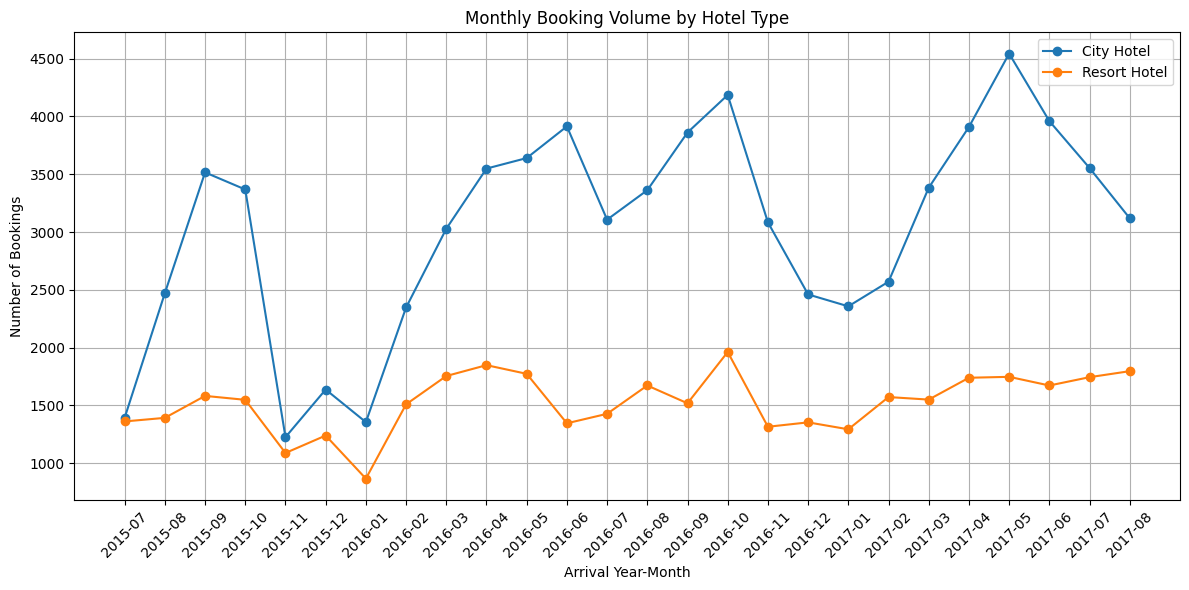

In [39]:
# Create line chart for monthly booking volume by hotel type
plt.figure(figsize=(12, 6))

for hotel_type, group_data in monthly_bookings.groupby("hotel"):
    plt.plot(
        group_data["arrival_year_month"],
        group_data["total_bookings"],
        marker="o",
        label=hotel_type
    )

plt.title("Monthly Booking Volume by Hotel Type")
plt.xlabel("Arrival Year-Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

save_and_show_plot("monthly_booking_volume_by_hotel_type.png")

Key observations:
- City hotels show higher booking volume than resort hotels across most months in the observed period.
- City hotel booking volume shows stronger monthly fluctuation, with noticeable peaks in selected spring and fall months during the observed period.
- Resort hotel booking volume remains lower and relatively more stable compared with city hotel booking volume.
- This chart includes both canceled and non-canceled bookings, so it reflects reservation activity rather than actual completed stays.

In [40]:
# Calculate monthly cancellation rate by hotel type
monthly_cancellation = (
    hotel.groupby(["arrival_year_month", "hotel"])["is_canceled"]
    .mean()
    .mul(100)
    .reset_index(name="cancellation_rate")
)

# Preview monthly cancellation rate table
monthly_cancellation.head()

,arrival_year_month,hotel,cancellation_rate
0,2015-07,City Hotel,67.408471
1,2015-07,Resort Hotel,23.512123
2,2015-08,City Hotel,49.858357
3,2015-08,Resort Hotel,26.293103
4,2015-09,City Hotel,43.856655


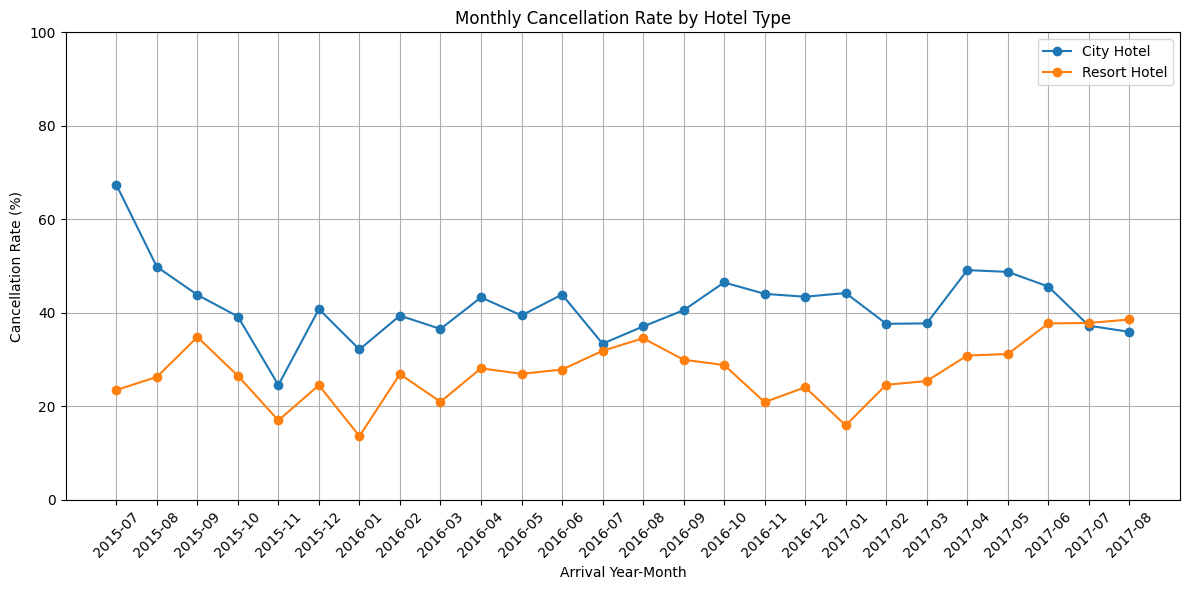

In [41]:
# Create line chart for monthly cancellation rate by hotel type
plt.figure(figsize=(12, 6))

for hotel_type, group_data in monthly_cancellation.groupby("hotel"):
    plt.plot(
        group_data["arrival_year_month"],
        group_data["cancellation_rate"],
        marker="o",
        label=hotel_type
    )

plt.title("Monthly Cancellation Rate by Hotel Type")
plt.xlabel("Arrival Year-Month")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.legend()
plt.grid(True)

save_and_show_plot("monthly_cancellation_rate_by_hotel_type.png")

Key observations:
- City hotels generally show higher cancellation rates than resort hotels across most months in the observed period.
- Cancellation rates fluctuate over time for both hotel types, suggesting that cancellation risk is not constant throughout the year.
- The gap between city hotel and resort hotel cancellation rates becomes smaller in some later months, especially around mid-to-late 2017.
- This matters for revenue management because higher booking volume does not necessarily translate into realized stays or realized revenue when cancellation rates are also high.

### Cancellation Rate by Lead Time Group

This analysis examines whether cancellation rates differ based on how far in advance guests made their bookings.

Lead time is grouped into categories to make cancellation behavior easier to compare across short-term, medium-term, and long-term advance bookings.

In [42]:
# Calculate cancellation rate by lead time group
lead_time_cancellation = (
    hotel.groupby("lead_time_group", observed=True)
    .agg(
        total_bookings=("is_canceled", "count"),
        canceled_bookings=("is_canceled", "sum"),
        cancellation_rate=("is_canceled", "mean")
    )
    .reset_index()
)

# Convert cancellation rate to percentage
lead_time_cancellation["cancellation_rate"] = lead_time_cancellation["cancellation_rate"] * 100

# Display the summary table
lead_time_cancellation

,lead_time_group,total_bookings,canceled_bookings,cancellation_rate
0,0-7 days,19246,1873,9.731892
1,8-30 days,18848,5277,27.997666
2,31-90 days,29437,11137,37.833339
3,91-180 days,26384,11818,44.792298
4,181-365 days,21505,11942,55.531272
5,365+ days,3144,2129,67.716285


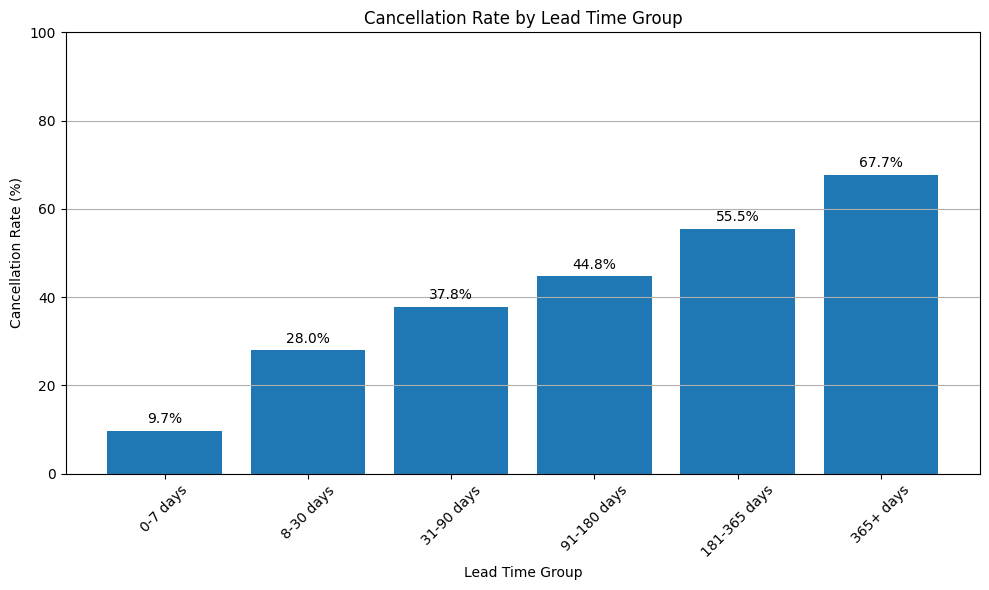

In [43]:
# Create bar chart for cancellation rate by lead time group
plt.figure(figsize=(10, 6))

bars = plt.bar(
    lead_time_cancellation["lead_time_group"].astype(str),
    lead_time_cancellation["cancellation_rate"]
)

# Add percentage labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Cancellation Rate by Lead Time Group")
plt.xlabel("Lead Time Group")
plt.ylabel("Cancellation Rate (%)")
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.grid(axis="y")

save_and_show_plot("cancellation_rate_by_lead_time_group.png")

Key observations:

- Cancellation rates increase consistently as lead time becomes longer.
- Bookings made within 0–7 days have the lowest cancellation rate at approximately 9.7%.
- Bookings made 365+ days in advance have the highest cancellation rate at approximately 67.7%, although this group has fewer total bookings than most other lead time groups.
- The increase across lead time groups suggests that lead time can be used as an early signal of cancellation risk.
- This result shows an association between lead time and cancellation behavior, but it should not be interpreted as proof that long lead time directly causes cancellations.

### Monthly ADR Trend by Hotel Type

This analysis examines how average daily rate changes over time for city hotels and resort hotels.

Only non-canceled bookings from the `hotel_revenue` dataset are used for this analysis because ADR and revenue-related insights should focus on bookings that converted into realized stays.

In [44]:
# Create a dataset for non-canceled bookings in the revenue analysis dataset
hotel_revenue_completed = hotel_revenue[hotel_revenue["is_canceled"] == 0].copy()

# Check the size of the completed revenue dataset
hotel_revenue_completed.shape

(73388, 40)

In [45]:
# Calculate monthly average ADR by hotel type using non-canceled bookings
monthly_adr = (
    hotel_revenue_completed
    .groupby(["arrival_year_month", "hotel"])["adr"]
    .mean()
    .reset_index(name="average_adr")
)

# Preview monthly ADR table
monthly_adr.head()

,arrival_year_month,hotel,average_adr
0,2015-07,City Hotel,80.233943
1,2015-07,Resort Hotel,127.510751
2,2015-08,City Hotel,86.670892
3,2015-08,Resort Hotel,156.233959
4,2015-09,City Hotel,107.318779


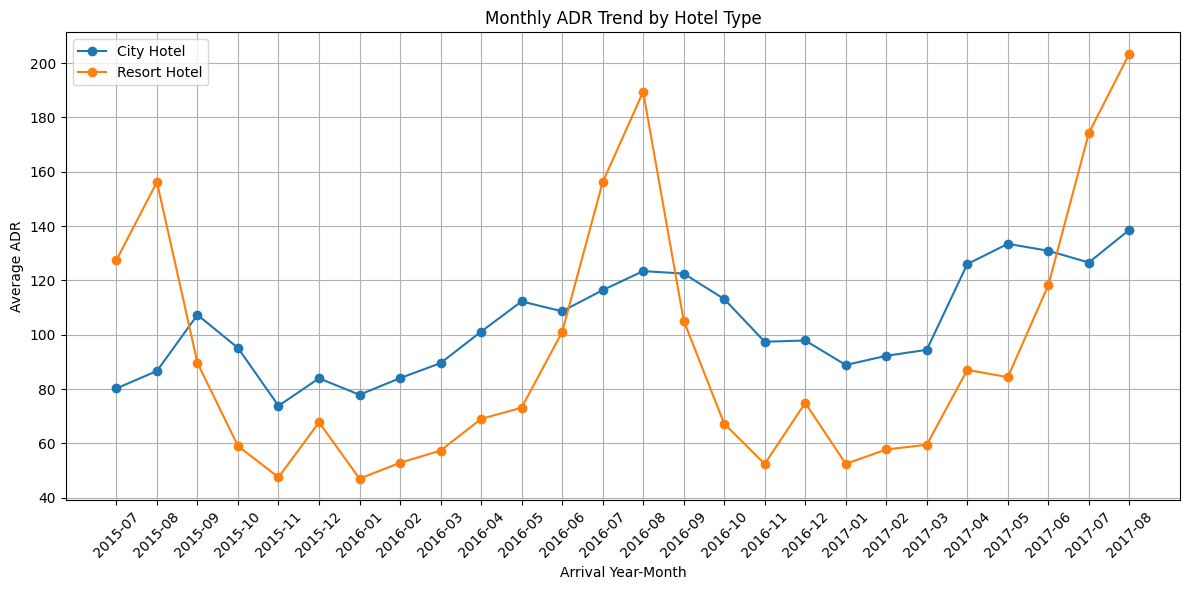

In [46]:
# Create line chart for monthly ADR trend by hotel type
plt.figure(figsize=(12, 6))

for hotel_type, group_data in monthly_adr.groupby("hotel"):
    plt.plot(
        group_data["arrival_year_month"],
        group_data["average_adr"],
        marker="o",
        label=hotel_type
    )

plt.title("Monthly ADR Trend by Hotel Type")
plt.xlabel("Arrival Year-Month")
plt.ylabel("Average ADR")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

save_and_show_plot("monthly_adr_trend_by_hotel_type.png")

Key observations:

- Resort hotels show stronger ADR fluctuation than city hotels during the observed period.
- Resort hotel ADR increases sharply during selected summer months, especially around August 2016 and July–August 2017.
- City hotel ADR appears more stable than resort hotel ADR and shows a gradual upward trend over time.
- Resort hotels have higher ADR than city hotels during peak leisure-season months, while city hotels often show higher ADR during several off-peak periods.
- This suggests that resort hotel pricing may be more seasonal, while city hotel pricing appears relatively more consistent across months.
- This analysis uses only non-canceled bookings from the `hotel_revenue` dataset, so the chart focuses on bookings that converted into realized stays.

### Cancellation Rate by Market Segment

This analysis compares cancellation rates across market segments.

The purpose of this visualization is to identify which customer or booking segments are associated with higher cancellation risk. This can help hotels make more informed decisions about booking policies, channel strategy, and cancellation risk management.

In [47]:
# Calculate cancellation rate by market segment
market_cancellation = (
    hotel.groupby("market_segment")
    .agg(
        total_bookings=("is_canceled", "count"),
        canceled_bookings=("is_canceled", "sum"),
        cancellation_rate=("is_canceled", "mean")
    )
    .reset_index()
)

# Convert cancellation rate to percentage
market_cancellation["cancellation_rate"] = market_cancellation["cancellation_rate"] * 100

# Sort by cancellation rate
market_cancellation = market_cancellation.sort_values(
    "cancellation_rate",
    ascending=False
)

# Display the summary table
market_cancellation

,market_segment,total_bookings,canceled_bookings,cancellation_rate
7,Undefined,2,2,100.000000
4,Groups,19758,12093,61.205588
6,Online TA,56129,20723,36.920309
5,Offline TA/TO,24049,8301,34.517028
0,Aviation,231,51,22.077922
2,Corporate,5231,989,18.906519
3,Direct,12449,1930,15.503253
1,Complementary,715,87,12.167832


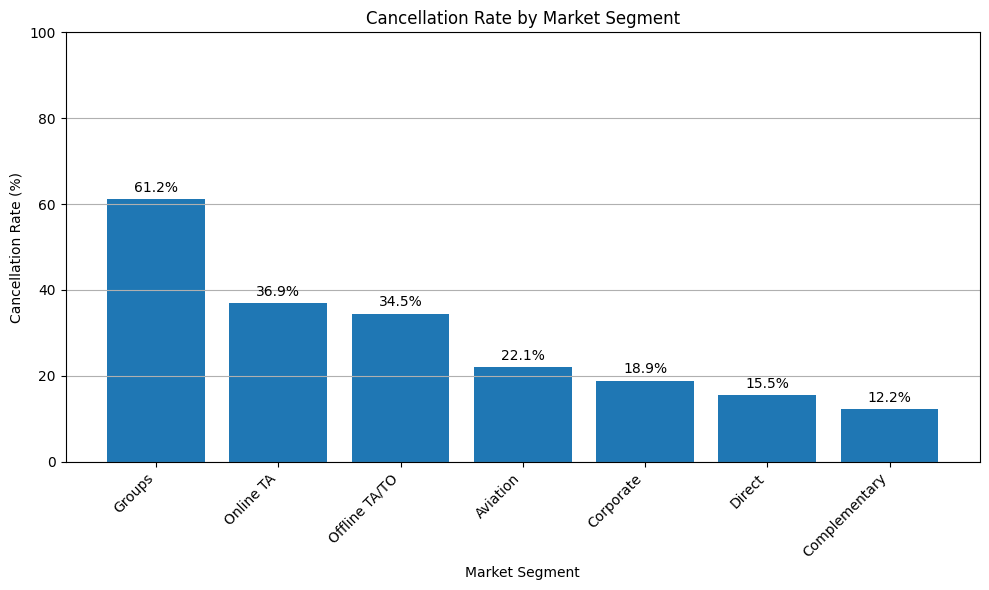

In [48]:
# Exclude very small market segments from visualization to avoid misleading interpretation
# "Undefined" has only 2 bookings, so its 100% cancellation rate is not reliable for visual comparison
market_cancellation_plot = market_cancellation[
    market_cancellation["total_bookings"] >= 100
].copy()

# Create bar chart for cancellation rate by market segment
plt.figure(figsize=(10, 6))

bars = plt.bar(
    market_cancellation_plot["market_segment"],
    market_cancellation_plot["cancellation_rate"]
)

# Add percentage labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Cancellation Rate (%)")
plt.ylim(0, 100)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")

save_and_show_plot("cancellation_rate_by_market_segment.png")

Key observations:

- Among market segments with sufficient booking volume, `Groups` has the highest cancellation rate at approximately 61.2%.
- `Online TA` and `Offline TA/TO` also show relatively high cancellation rates, at approximately 36.9% and 34.5%.
- `Direct` and `Complementary` show lower cancellation rates compared with most other market segments.
- The `Undefined` segment was excluded from the visualization because it had only 2 total bookings, making its 100% cancellation rate unreliable for visual comparison.
- These results suggest that cancellation risk differs by market segment, so hotels may need different cancellation management strategies depending on the source or type of booking.

### Average ADR by Market Segment

This analysis compares average daily rate across market segments using non-canceled bookings from the `hotel_revenue` dataset.

The purpose of this visualization is to identify which market segments are associated with higher realized room rates. This helps compare segment value with the cancellation risk patterns observed in the previous analysis.

In [49]:
# Calculate average ADR by market segment using non-canceled bookings
market_adr = (
    hotel_revenue_completed.groupby("market_segment")
    .agg(
        completed_bookings=("adr", "count"),
        average_adr=("adr", "mean"),
        median_adr=("adr", "median")
    )
    .reset_index()
)

# Sort by average ADR
market_adr = market_adr.sort_values(
    "average_adr",
    ascending=False
)

# Display the summary table
market_adr

,market_segment,completed_bookings,average_adr,median_adr
3,Direct,10458,116.168362,105.00
6,Online TA,35370,115.012042,107.95
0,Aviation,180,102.245444,95.00
5,Offline TA/TO,15614,84.978373,81.00
4,Groups,7484,79.495151,73.33
2,Corporate,4224,68.358790,65.00
1,Complementary,58,34.288621,20.00


In [50]:
# Exclude very small market segments from visualization to avoid misleading interpretation
market_adr_plot = market_adr[
    market_adr["completed_bookings"] >= 100
].copy()

# Display the plotting dataset
market_adr_plot

,market_segment,completed_bookings,average_adr,median_adr
3,Direct,10458,116.168362,105.00
6,Online TA,35370,115.012042,107.95
0,Aviation,180,102.245444,95.00
5,Offline TA/TO,15614,84.978373,81.00
4,Groups,7484,79.495151,73.33
2,Corporate,4224,68.358790,65.00


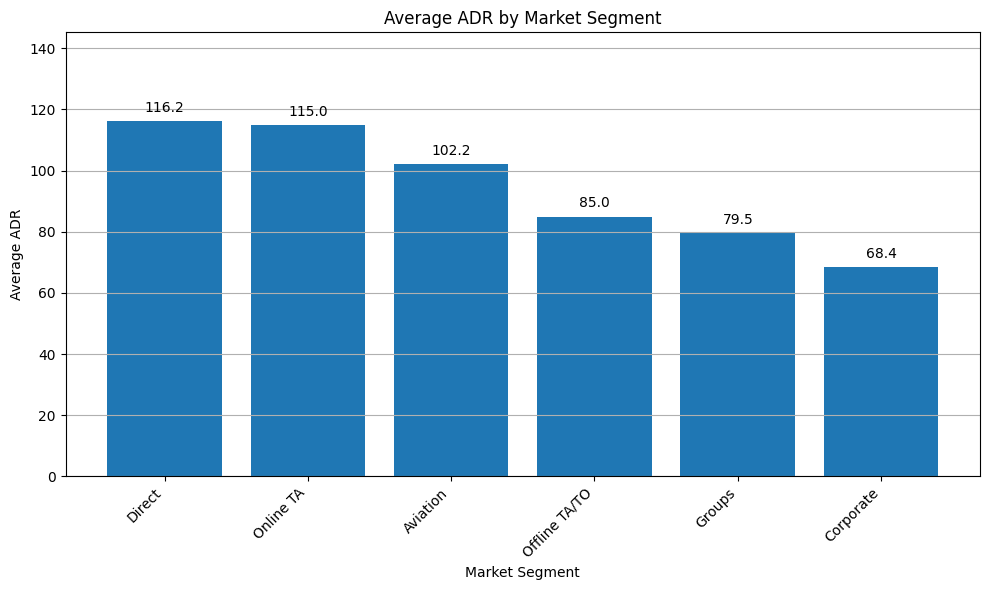

In [51]:
# Create bar chart for average ADR by market segment
plt.figure(figsize=(10, 6))

bars = plt.bar(
    market_adr_plot["market_segment"],
    market_adr_plot["average_adr"]
)

# Add ADR labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{height:.1f}",
        ha="center",
        va="bottom"
    )

plt.title("Average ADR by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Average ADR")
plt.ylim(0, market_adr_plot["average_adr"].max() * 1.25)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")

save_and_show_plot("average_adr_by_market_segment.png")

#### Key observations:

- Direct shows the highest average ADR among the market segments included in the visualization, followed closely by Online TA.
- Online TA combines a relatively high average ADR with a much higher cancellation rate than Direct, suggesting strong revenue potential but greater booking risk.
- Aviation also shows a relatively high ADR, but its completed booking volume is much smaller than major segments such as Direct, Online TA, and Offline TA/TO, so this result should be interpreted more cautiously.
- Offline TA/TO and Groups generate lower average ADR than Direct and Online TA, while Groups were also associated with the highest cancellation rate in the previous analysis.
- Corporate shows the lowest average ADR among the plotted segments, although its cancellation rate is lower than several other segments.
- Complimentary was excluded from the chart because the number of completed bookings was too small for reliable comparison.
- Overall, the results suggest that market segments differ not only in cancellation risk but also in realized pricing value, which is important for revenue management decisions.

### Realized Revenue Proxy by Market Segment

This analysis compares estimated realized room revenue across market segments using non-canceled bookings from the `hotel_revenue` dataset.

Since the dataset does not provide actual total room revenue, this project uses a revenue proxy calculated as ADR × total nights. This metric estimates room revenue contribution at the booking level.

In [52]:
# Calculate estimated realized revenue proxy by market segment
market_revenue = (
    hotel_revenue_completed.groupby("market_segment")
    .agg(
        completed_bookings=("revenue_proxy", "count"),
        total_realized_revenue_proxy=("revenue_proxy", "sum"),
        average_revenue_proxy_per_booking=("revenue_proxy", "mean"),
        average_adr=("adr", "mean")
    )
    .reset_index()
)

# Sort by total realized revenue proxy
market_revenue = market_revenue.sort_values(
    "total_realized_revenue_proxy",
    ascending=False
)

# Display the summary table
market_revenue

,market_segment,completed_bookings,total_realized_revenue_proxy,average_revenue_proxy_per_booking,average_adr
6,Online TA,35370,13707139.09,387.535739,115.012042
5,Offline TA/TO,15614,5659291.94,362.449849,84.978373
3,Direct,10458,4097842.40,391.838057,116.168362
4,Groups,7484,1869129.52,249.750069,79.495151
2,Corporate,4224,577892.19,136.811598,68.358790
0,Aviation,180,70868.36,393.713111,102.245444
1,Complementary,58,4812.53,82.974655,34.288621


In [53]:
# Exclude very small market segments from visualization to avoid misleading interpretation
market_revenue_plot = market_revenue[
    market_revenue["completed_bookings"] >= 100
].copy()

# Display the plotting dataset
market_revenue_plot

,market_segment,completed_bookings,total_realized_revenue_proxy,average_revenue_proxy_per_booking,average_adr
6,Online TA,35370,13707139.09,387.535739,115.012042
5,Offline TA/TO,15614,5659291.94,362.449849,84.978373
3,Direct,10458,4097842.40,391.838057,116.168362
4,Groups,7484,1869129.52,249.750069,79.495151
2,Corporate,4224,577892.19,136.811598,68.358790
0,Aviation,180,70868.36,393.713111,102.245444


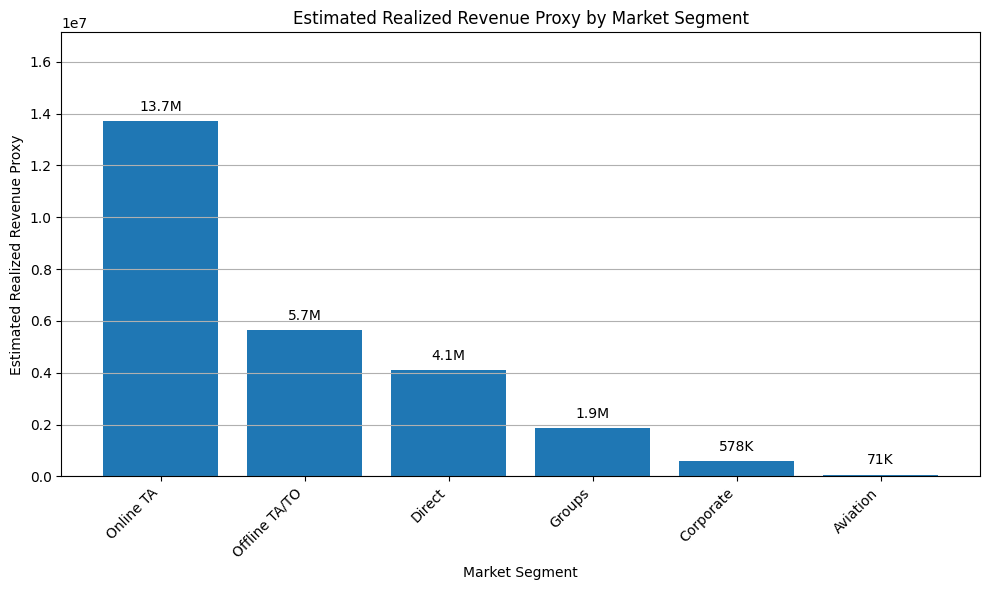

In [54]:
# Create bar chart for estimated realized revenue proxy by market segment
plt.figure(figsize=(10, 6))

bars = plt.bar(
    market_revenue_plot["market_segment"],
    market_revenue_plot["total_realized_revenue_proxy"]
)

# Add value labels above each bar
for bar in bars:
    height = bar.get_height()
    
    if height >= 1_000_000:
        label = f"{height / 1_000_000:.1f}M"
    else:
        label = f"{height / 1_000:.0f}K"
    
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + market_revenue_plot["total_realized_revenue_proxy"].max() * 0.02,
        label,
        ha="center",
        va="bottom"
    )

plt.title("Estimated Realized Revenue Proxy by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Estimated Realized Revenue Proxy")
plt.ylim(0, market_revenue_plot["total_realized_revenue_proxy"].max() * 1.25)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")

save_and_show_plot("realized_revenue_proxy_by_market_segment.png")

Key observations:

- `Online TA` contributes the highest estimated realized revenue proxy, at approximately 13.7M.
- `Offline TA/TO` is the second-largest contributor at approximately 5.7M, followed by `Direct` at approximately 4.1M.
- Although `Direct` had the highest average ADR in the previous analysis, it does not generate the highest total realized revenue proxy because its completed booking volume is lower than `Online TA`.
- `Online TA` combines high completed booking volume with relatively high ADR, making it the strongest revenue-contributing segment in this dataset.
- `Groups` generated approximately 1.9M in estimated realized revenue proxy, but this segment also showed the highest cancellation rate in the previous market segment analysis, indicating both revenue value and cancellation risk.
- `Corporate` and `Aviation` contribute much less total realized revenue proxy compared with the major travel agency and direct booking segments.
- Very small segments were excluded from the visualization to avoid misleading interpretation.
- This analysis uses a revenue proxy, not actual reported hotel revenue, because the dataset does not include actual total room revenue.

### Estimated Revenue at Risk by Market Segment

This analysis compares estimated revenue at risk across market segments.

Revenue at risk represents the estimated room revenue associated with canceled bookings. Since the dataset does not include actual total room revenue, this project uses the revenue proxy calculated as ADR × total nights.

The purpose of this analysis is to identify which market segments create the largest estimated revenue exposure from cancellations.

In [55]:
# Calculate estimated revenue at risk by market segment
market_revenue_risk = (
    hotel_revenue.groupby("market_segment")
    .agg(
        total_bookings=("is_canceled", "count"),
        canceled_bookings=("is_canceled", "sum"),
        cancellation_rate=("is_canceled", "mean"),
        total_revenue_at_risk=("revenue_at_risk", "sum"),
        average_adr=("adr", "mean")
    )
    .reset_index()
)

# Convert cancellation rate to percentage
market_revenue_risk["cancellation_rate"] = market_revenue_risk["cancellation_rate"] * 100

# Calculate average revenue at risk per canceled booking
market_revenue_risk["avg_revenue_at_risk_per_canceled_booking"] = np.where(
    market_revenue_risk["canceled_bookings"] > 0,
    market_revenue_risk["total_revenue_at_risk"] / market_revenue_risk["canceled_bookings"],
    0
)

# Sort by total revenue at risk
market_revenue_risk = market_revenue_risk.sort_values(
    "total_revenue_at_risk",
    ascending=False
)

# Display the summary table
market_revenue_risk

,market_segment,total_bookings,canceled_bookings,cancellation_rate,total_revenue_at_risk,average_adr,avg_revenue_at_risk_per_canceled_booking
6,Online TA,56089,20719,36.939507,10227646.11,117.985256,493.636088
4,Groups,19557,12073,61.732372,2800543.98,80.511879,231.967529
5,Offline TA/TO,23884,8270,34.625691,2486958.15,88.344691,300.720453
3,Direct,12361,1903,15.395195,993409.82,117.702005,522.023027
2,Corporate,5211,987,18.940702,196383.07,70.475657,198.969676
0,Aviation,231,51,22.077922,16578.00,102.743203,325.058824
1,Complementary,63,5,7.936508,269.99,34.040794,53.998000
7,Undefined,2,2,100.000000,48.00,15.000000,24.000000


In [56]:
# Exclude very small market segments from visualization to avoid misleading interpretation
market_revenue_risk_plot = market_revenue_risk[
    market_revenue_risk["total_bookings"] >= 100
].copy()

# Display the plotting dataset
market_revenue_risk_plot

,market_segment,total_bookings,canceled_bookings,cancellation_rate,total_revenue_at_risk,average_adr,avg_revenue_at_risk_per_canceled_booking
6,Online TA,56089,20719,36.939507,10227646.11,117.985256,493.636088
4,Groups,19557,12073,61.732372,2800543.98,80.511879,231.967529
5,Offline TA/TO,23884,8270,34.625691,2486958.15,88.344691,300.720453
3,Direct,12361,1903,15.395195,993409.82,117.702005,522.023027
2,Corporate,5211,987,18.940702,196383.07,70.475657,198.969676
0,Aviation,231,51,22.077922,16578.00,102.743203,325.058824


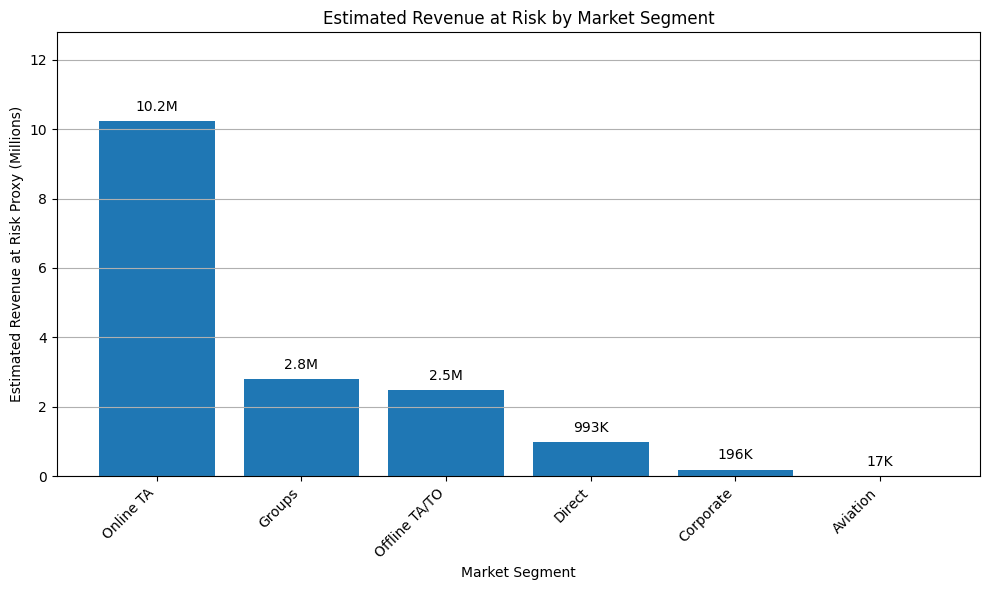

In [57]:
# Create a plotting column in millions for readability
market_revenue_risk_plot["total_revenue_at_risk_millions"] = (
    market_revenue_risk_plot["total_revenue_at_risk"] / 1_000_000
)

# Create bar chart for estimated revenue at risk by market segment
plt.figure(figsize=(10, 6))

bars = plt.bar(
    market_revenue_risk_plot["market_segment"],
    market_revenue_risk_plot["total_revenue_at_risk_millions"]
)

# Add value labels above each bar
for bar in bars:
    height = bar.get_height()
    
    if height >= 1:
        label = f"{height:.1f}M"
    else:
        label = f"{height * 1000:.0f}K"
    
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + market_revenue_risk_plot["total_revenue_at_risk_millions"].max() * 0.02,
        label,
        ha="center",
        va="bottom"
    )

plt.title("Estimated Revenue at Risk by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Estimated Revenue at Risk Proxy (Millions)")
plt.ylim(0, market_revenue_risk_plot["total_revenue_at_risk_millions"].max() * 1.25)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")

save_and_show_plot("revenue_at_risk_by_market_segment.png")

Key observations:

- `Online TA` has the highest estimated revenue at risk proxy, at approximately 10.2M.
- `Groups` has the second-highest estimated revenue at risk proxy at approximately 2.8M, followed by `Offline TA/TO` at approximately 2.5M.
- `Online TA` was also the largest contributor to estimated realized revenue proxy, which means it represents both major revenue value and major cancellation-related revenue exposure.
- `Groups` shows high revenue at risk despite generating less realized revenue than `Online TA`, which aligns with its high cancellation rate from the previous market segment analysis.
- `Direct` contributes much lower revenue at risk than `Online TA`, even though it showed high average ADR, because its cancellation rate and booking volume are lower.
- `Corporate` and `Aviation` show relatively low estimated revenue at risk compared with the major travel agency and group segments.
- Very small segments were excluded from the visualization to avoid misleading interpretation.
- This chart uses estimated revenue at risk based on the revenue proxy, not actual reported hotel revenue.

### Market Segment Risk-Value Summary

This analysis combines cancellation risk and estimated realized revenue contribution by market segment.

The purpose is to identify which market segments represent high revenue value, high cancellation risk, or both. This provides a more actionable view for revenue management than looking at ADR, cancellation rate, or revenue contribution separately.

In [58]:
# Create cancellation risk summary by market segment
segment_risk = (
    hotel_revenue.groupby("market_segment")
    .agg(
        total_bookings=("is_canceled", "count"),
        canceled_bookings=("is_canceled", "sum"),
        cancellation_rate=("is_canceled", "mean"),
        total_revenue_at_risk=("revenue_at_risk", "sum")
    )
    .reset_index()
)

# Convert cancellation rate to percentage
segment_risk["cancellation_rate"] = segment_risk["cancellation_rate"] * 100

# Create realized revenue summary using non-canceled bookings only
segment_value = (
    hotel_revenue_completed.groupby("market_segment")
    .agg(
        completed_bookings=("is_canceled", "count"),
        average_adr=("adr", "mean"),
        total_realized_revenue_proxy=("revenue_proxy", "sum")
    )
    .reset_index()
)

# Combine risk and value summaries
segment_scorecard = segment_risk.merge(
    segment_value,
    on="market_segment",
    how="left"
)

# Fill missing values for segments with no completed bookings
segment_scorecard[[
    "completed_bookings",
    "average_adr",
    "total_realized_revenue_proxy"
]] = segment_scorecard[[
    "completed_bookings",
    "average_adr",
    "total_realized_revenue_proxy"
]].fillna(0)

# Calculate revenue at risk as a percentage of realized revenue proxy
segment_scorecard["risk_to_realized_revenue_ratio"] = np.where(
    segment_scorecard["total_realized_revenue_proxy"] > 0,
    segment_scorecard["total_revenue_at_risk"] / segment_scorecard["total_realized_revenue_proxy"] * 100,
    np.nan
)

# Sort by estimated revenue at risk
segment_scorecard = segment_scorecard.sort_values(
    "total_revenue_at_risk",
    ascending=False
)

# Display the segment scorecard
segment_scorecard

,market_segment,total_bookings,canceled_bookings,cancellation_rate,total_revenue_at_risk,completed_bookings,average_adr,total_realized_revenue_proxy,risk_to_realized_revenue_ratio
6,Online TA,56089,20719,36.939507,10227646.11,35370.0,115.012042,13707139.09,74.615469
4,Groups,19557,12073,61.732372,2800543.98,7484.0,79.495151,1869129.52,149.831456
5,Offline TA/TO,23884,8270,34.625691,2486958.15,15614.0,84.978373,5659291.94,43.944687
3,Direct,12361,1903,15.395195,993409.82,10458.0,116.168362,4097842.40,24.242265
2,Corporate,5211,987,18.940702,196383.07,4224.0,68.358790,577892.19,33.982648
0,Aviation,231,51,22.077922,16578.00,180.0,102.245444,70868.36,23.392668
1,Complementary,63,5,7.936508,269.99,58.0,34.288621,4812.53,5.610147
7,Undefined,2,2,100.000000,48.00,0.0,0.000000,0.00,NaN


In [59]:
# Exclude very small segments from visualization to avoid misleading interpretation
segment_scorecard_plot = segment_scorecard[
    segment_scorecard["total_bookings"] >= 100
].copy()

# Convert revenue values to millions for visualization
segment_scorecard_plot["realized_revenue_millions"] = (
    segment_scorecard_plot["total_realized_revenue_proxy"] / 1_000_000
)

segment_scorecard_plot["revenue_at_risk_millions"] = (
    segment_scorecard_plot["total_revenue_at_risk"] / 1_000_000
)

# Display plotting dataset
segment_scorecard_plot

,market_segment,total_bookings,canceled_bookings,cancellation_rate,total_revenue_at_risk,completed_bookings,average_adr,total_realized_revenue_proxy,risk_to_realized_revenue_ratio,realized_revenue_millions,revenue_at_risk_millions
6,Online TA,56089,20719,36.939507,10227646.11,35370.0,115.012042,13707139.09,74.615469,13.707139,10.227646
4,Groups,19557,12073,61.732372,2800543.98,7484.0,79.495151,1869129.52,149.831456,1.869130,2.800544
5,Offline TA/TO,23884,8270,34.625691,2486958.15,15614.0,84.978373,5659291.94,43.944687,5.659292,2.486958
3,Direct,12361,1903,15.395195,993409.82,10458.0,116.168362,4097842.40,24.242265,4.097842,0.993410
2,Corporate,5211,987,18.940702,196383.07,4224.0,68.358790,577892.19,33.982648,0.577892,0.196383
0,Aviation,231,51,22.077922,16578.00,180.0,102.245444,70868.36,23.392668,0.070868,0.016578


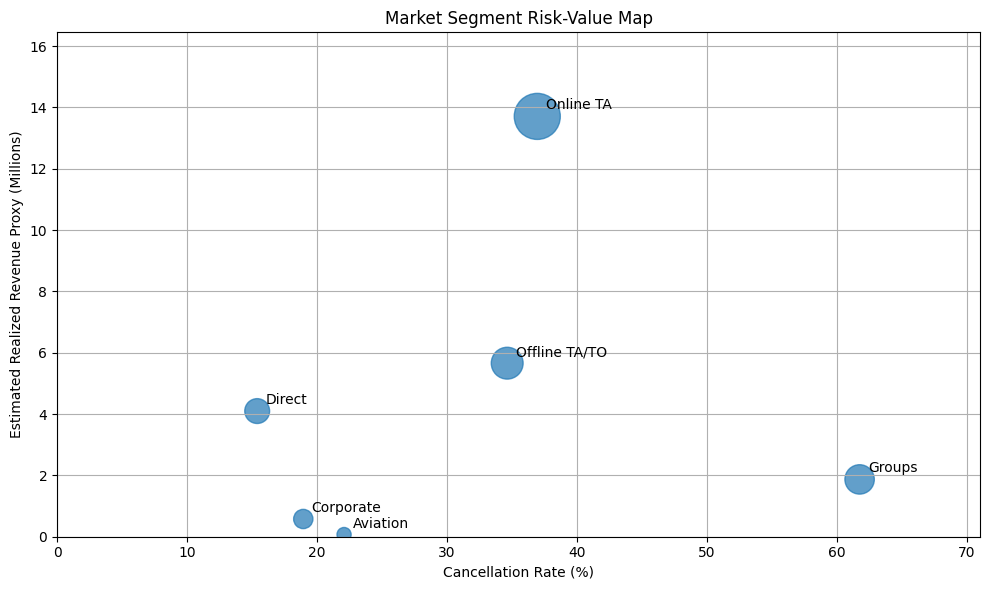

In [60]:
# Create a risk-value scatter plot by market segment
plt.figure(figsize=(10, 6))

# Point size represents total booking volume
point_sizes = (
    segment_scorecard_plot["total_bookings"] / segment_scorecard_plot["total_bookings"].max()
) * 1000 + 100

plt.scatter(
    segment_scorecard_plot["cancellation_rate"],
    segment_scorecard_plot["realized_revenue_millions"],
    s=point_sizes,
    alpha=0.7
)

# Add market segment labels
for _, row in segment_scorecard_plot.iterrows():
    plt.annotate(
        row["market_segment"],
        (
            row["cancellation_rate"],
            row["realized_revenue_millions"]
        ),
        textcoords="offset points",
        xytext=(6, 5)
    )

plt.title("Market Segment Risk-Value Map")
plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Estimated Realized Revenue Proxy (Millions)")
plt.xlim(0, segment_scorecard_plot["cancellation_rate"].max() * 1.15)
plt.ylim(0, segment_scorecard_plot["realized_revenue_millions"].max() * 1.20)
plt.grid(True)

save_and_show_plot("market_segment_risk_value_map.png")

Key observations:

- `Online TA` stands out as the most important segment in this risk-value map because it combines the highest estimated realized revenue proxy with a meaningful cancellation rate.
- `Groups` has the highest cancellation rate among the plotted segments, but its estimated realized revenue proxy is much lower than `Online TA`.
- `Direct` shows a relatively favorable position because it has high estimated realized revenue proxy with a much lower cancellation rate compared with `Online TA`, `Groups`, and `Offline TA/TO`.
- `Offline TA/TO` has moderate-to-high cancellation risk and the second-highest estimated realized revenue proxy among the plotted segments.
- `Corporate` and `Aviation` show lower estimated realized revenue contribution and lower overall booking volume compared with the major market segments.
- Point size represents total booking volume, so larger points indicate segments with greater booking activity.
- Very small segments were excluded from the visualization to avoid misleading interpretation.
- From a revenue management perspective, `Online TA` should be monitored closely because it represents both high revenue value and high cancellation-related exposure, while `Direct` appears to be a more stable high-value segment.

### Hotel Type Revenue and Cancellation Summary

This analysis summarizes cancellation rate, ADR, estimated realized revenue proxy, and estimated revenue at risk by hotel type.

The purpose is to compare city hotels and resort hotels from both a demand-risk and revenue contribution perspective.

In [61]:
# Create hotel type performance summary using the revenue analysis dataset
hotel_type_performance = (
    hotel_revenue.groupby("hotel")
    .agg(
        total_bookings=("is_canceled", "count"),
        canceled_bookings=("is_canceled", "sum"),
        cancellation_rate=("is_canceled", "mean"),
        average_adr=("adr", "mean"),
        total_revenue_proxy=("revenue_proxy", "sum"),
        total_realized_revenue_proxy=("realized_revenue_proxy", "sum"),
        total_revenue_at_risk=("revenue_at_risk", "sum")
    )
    .reset_index()
)

# Convert cancellation rate to percentage
hotel_type_performance["cancellation_rate"] = (
    hotel_type_performance["cancellation_rate"] * 100
)

# Calculate revenue at risk as a percentage of realized revenue proxy
hotel_type_performance["risk_to_realized_revenue_ratio"] = np.where(
    hotel_type_performance["total_realized_revenue_proxy"] > 0,
    hotel_type_performance["total_revenue_at_risk"] / hotel_type_performance["total_realized_revenue_proxy"] * 100,
    np.nan
)

# Sort by estimated realized revenue proxy
hotel_type_performance = hotel_type_performance.sort_values(
    "total_realized_revenue_proxy",
    ascending=False
)

# Display the summary table
hotel_type_performance

,hotel,total_bookings,canceled_bookings,cancellation_rate,average_adr,total_revenue_proxy,total_realized_revenue_proxy,total_revenue_at_risk,risk_to_realized_revenue_ratio
0,City Hotel,78091,32972,42.222535,106.882343,25265001.78,14385342.00,10879659.78,75.630178
1,Resort Hotel,39307,11038,28.081512,96.771383,17443811.37,11601634.03,5842177.34,50.356504


In [62]:
# Create plotting columns in millions for readability
hotel_type_performance_plot = hotel_type_performance.copy()

hotel_type_performance_plot["realized_revenue_millions"] = (
    hotel_type_performance_plot["total_realized_revenue_proxy"] / 1_000_000
)

hotel_type_performance_plot["revenue_at_risk_millions"] = (
    hotel_type_performance_plot["total_revenue_at_risk"] / 1_000_000
)

# Display plotting dataset
hotel_type_performance_plot[[
    "hotel",
    "cancellation_rate",
    "average_adr",
    "realized_revenue_millions",
    "revenue_at_risk_millions",
    "risk_to_realized_revenue_ratio"
]]

,hotel,cancellation_rate,average_adr,realized_revenue_millions,revenue_at_risk_millions,risk_to_realized_revenue_ratio
0,City Hotel,42.222535,106.882343,14.385342,10.879660,75.630178
1,Resort Hotel,28.081512,96.771383,11.601634,5.842177,50.356504


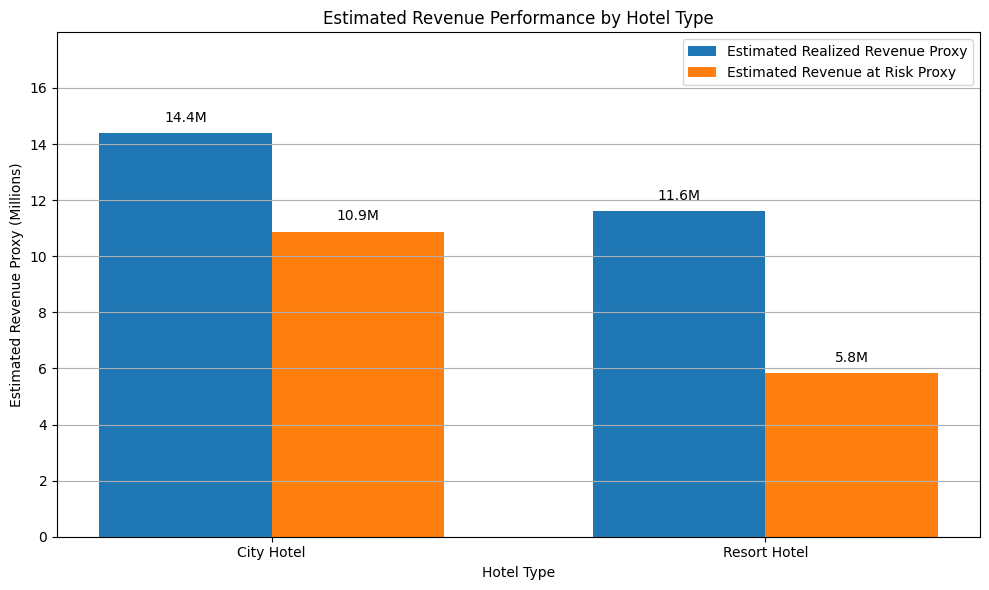

In [63]:
# Create grouped bar chart for realized revenue proxy and revenue at risk by hotel type
x = np.arange(len(hotel_type_performance_plot["hotel"]))
width = 0.35

plt.figure(figsize=(10, 6))

bars_realized = plt.bar(
    x - width / 2,
    hotel_type_performance_plot["realized_revenue_millions"],
    width,
    label="Estimated Realized Revenue Proxy"
)

bars_risk = plt.bar(
    x + width / 2,
    hotel_type_performance_plot["revenue_at_risk_millions"],
    width,
    label="Estimated Revenue at Risk Proxy"
)

# Add value labels above each bar
for bars in [bars_realized, bars_risk]:
    for bar in bars:
        height = bar.get_height()
        label = f"{height:.1f}M"
        
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + max(
                hotel_type_performance_plot["realized_revenue_millions"].max(),
                hotel_type_performance_plot["revenue_at_risk_millions"].max()
            ) * 0.02,
            label,
            ha="center",
            va="bottom"
        )

plt.title("Estimated Revenue Performance by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Estimated Revenue Proxy (Millions)")
plt.xticks(x, hotel_type_performance_plot["hotel"])
plt.ylim(
    0,
    max(
        hotel_type_performance_plot["realized_revenue_millions"].max(),
        hotel_type_performance_plot["revenue_at_risk_millions"].max()
    ) * 1.25
)
plt.legend()
plt.grid(axis="y")

save_and_show_plot("hotel_type_revenue_performance.png")

Key observations:

- City hotels generate higher estimated realized revenue proxy than resort hotels, at approximately 14.4M compared with 11.6M.
- City hotels also have higher estimated revenue at risk proxy, at approximately 10.9M compared with 5.8M for resort hotels.
- City hotels show a higher cancellation rate than resort hotels, approximately 42.2% versus 28.1%.
- City hotels also have a slightly higher average ADR than resort hotels in this revenue analysis dataset.
- The risk-to-realized revenue ratio is higher for city hotels, suggesting that city hotel revenue is more exposed to cancellation-related risk.
- Resort hotels generate lower estimated realized revenue proxy, but they also show lower cancellation-related revenue exposure compared with city hotels.
- Overall, city hotels appear to be the stronger revenue contributor, but they also carry greater cancellation-related revenue risk.
- This chart uses estimated revenue proxy values, not actual reported hotel revenue.

## 6. Key Findings

This section summarizes the main findings from the exploratory data analysis.

### Finding 1: City hotels show stronger booking volume but also higher cancellation risk.

City hotels recorded higher booking volume than resort hotels across most months in the observed period. However, city hotels also showed higher cancellation rates and higher estimated revenue at risk. This suggests that stronger booking demand does not automatically translate into lower revenue risk.

### Finding 2: Longer lead time is associated with higher cancellation rates.

Cancellation rates increased consistently as lead time became longer. Bookings made within 0–7 days had the lowest cancellation rate at approximately 9.7%, while bookings made 365+ days in advance had the highest cancellation rate at approximately 67.7%. This suggests that lead time can be used as an early indicator of cancellation risk.

### Finding 3: Market segments differ significantly in both value and risk.

`Online TA` generated the highest estimated realized revenue proxy and also the highest estimated revenue at risk proxy. `Groups` had the highest cancellation rate among major market segments, while `Direct` showed a stronger balance of high ADR, meaningful revenue contribution, and lower cancellation risk.

### Finding 4: High ADR does not always mean the highest total revenue contribution.

`Direct` had the highest average ADR among major market segments, but `Online TA` generated the highest estimated realized revenue proxy because it had much higher completed booking volume. This shows that revenue contribution depends on both price and volume.

### Finding 5: Revenue management decisions should consider both cancellation risk and revenue value.

Segments with high booking volume or high ADR may still create substantial revenue exposure if cancellation rates are also high. A combined risk-value view is more useful than analyzing ADR, booking volume, or cancellation rate separately.

## 7. Business Recommendations

Based on the findings from the exploratory data analysis, the following recommendations focus on cancellation risk management, segment strategy, and revenue protection.

### Recommendation 1: Use lead time as an early cancellation risk signal.

Bookings with longer lead times showed much higher cancellation rates than short lead-time bookings. Hotels should monitor long lead-time reservations more carefully, especially bookings made more than 180 days in advance.

Possible actions include:
- sending reminder emails before arrival,
- requiring stronger confirmation for long lead-time bookings,
- reviewing deposit or cancellation policies for high-risk booking windows,
- adjusting forecasts based on expected cancellation risk.

This can help hotels identify uncertain bookings earlier and reduce the gap between reservation demand and realized stays.

### Recommendation 2: Manage Online TA bookings as both high-value and high-risk.

`Online TA` generated the highest estimated realized revenue proxy, but it also created the highest estimated revenue at risk proxy. This means Online TA is an important revenue source, but it also requires careful cancellation management.

Hotels should not simply reduce Online TA reliance because it contributes substantial revenue. Instead, they should manage this segment with stronger cancellation forecasting, targeted reminders, and channel-specific booking policies.

### Recommendation 3: Review Group booking policies because of high cancellation risk.

`Groups` showed the highest cancellation rate among major market segments and also represented meaningful estimated revenue at risk. This suggests that group bookings may need more structured risk controls.

Possible actions include:
- clearer deposit requirements,
- earlier reconfirmation deadlines,
- staged cancellation penalties,
- closer monitoring of large group blocks.

These policies can help reduce uncertainty from group reservations while still preserving group revenue opportunities.

### Recommendation 4: Strengthen Direct booking strategy.

`Direct` bookings showed high average ADR and lower cancellation risk compared with several major third-party segments. This suggests that direct bookings may provide a more stable high-value revenue source.

Hotels could encourage more direct bookings through loyalty benefits, direct-channel price advantages, personalized offers, or clearer cancellation terms. A stronger direct booking strategy may help improve revenue stability and reduce dependence on higher-risk channels.

### Recommendation 5: Use a risk-value approach instead of looking at one metric alone.

The analysis shows that ADR, booking volume, cancellation rate, realized revenue proxy, and revenue at risk can tell different stories. For example, `Direct` had the highest average ADR, but `Online TA` contributed the highest estimated realized revenue proxy because of its larger booking volume.

Revenue management decisions should therefore combine multiple indicators rather than relying on one metric. A segment with high ADR is not always the largest revenue contributor, and a high-volume segment may also create significant cancellation-related exposure.

## 8. Limitations

This project uses a public hotel booking demand dataset, so several limitations should be considered when interpreting the results.

First, the dataset does not include actual reported total room revenue. Therefore, this project uses a revenue proxy calculated as ADR × total nights. This proxy is useful for comparing patterns across segments, but it should not be interpreted as actual hotel revenue.

Second, the dataset includes booking-level records, but it does not provide full information about hotel capacity, room inventory, operating costs, or profit margins. As a result, the analysis focuses on booking demand, ADR, cancellation risk, and estimated room revenue proxy rather than full hotel profitability.

Third, the analysis is based on historical data from the observed period. Booking behavior, channel mix, cancellation policies, and market conditions may change over time, so the findings should not be assumed to apply directly to all hotels or future periods.

Fourth, this project identifies associations between variables such as lead time, market segment, hotel type, and cancellation behavior. These relationships should not be interpreted as causal without additional statistical testing or experimental evidence.

Finally, some very small market segments were excluded from selected visualizations to avoid misleading interpretation. This improves the reliability of the charts, but it also means that the visual analysis focuses mainly on segments with sufficient booking volume.

## 9. Conclusion

This project analyzed hotel booking demand data to understand booking patterns, cancellation risk, ADR trends, and estimated revenue exposure across hotel types and market segments.

The analysis found that city hotels generally had stronger booking volume and higher estimated realized revenue proxy than resort hotels, but they also showed higher cancellation rates and greater estimated revenue at risk. This suggests that high demand can still create revenue uncertainty when cancellation risk is also high.

Lead time was one of the clearest cancellation risk indicators in the project. Cancellation rates increased steadily as lead time became longer, showing that bookings made far in advance are less certain to convert into realized stays.

Market segment analysis also showed that revenue value and cancellation risk vary meaningfully across segments. `Online TA` was the largest estimated realized revenue contributor, but it also created the largest estimated revenue at risk. `Groups` showed the highest cancellation rate among major segments, while `Direct` bookings showed a stronger balance of high ADR and lower cancellation risk.

Overall, the project shows that hotel revenue management decisions should not rely on booking volume, ADR, or cancellation rate alone. A more useful approach is to combine demand, pricing, cancellation risk, and estimated revenue exposure to identify where hotels should focus forecasting, cancellation management, and channel strategy.

## 10. Project Files and Reproducibility

The analysis was completed in a Kaggle Notebook using Python, pandas, NumPy, and Matplotlib.

The main dataset used in this project is the public Hotel Booking Demand dataset. The workflow includes data loading, initial inspection, data cleaning, feature engineering, exploratory data analysis, and business recommendations.

To support reproducibility, the notebook is organized into clear sections with code cells, markdown explanations, visualizations, key observations, limitations, and final conclusions.

The charts created in this notebook were also saved as image files in the Kaggle working directory for future use in GitHub documentation or portfolio materials.